<a href="https://colab.research.google.com/github/Gurkamal-kaur/Business-project-part-2/blob/main/market_basket_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Step 1: Import Libraries

# Core data analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning (optional, for clustering or modeling later)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score

# Date/time handling
import datetime as dt

# Google Drive file download
!pip install gdown
import gdown


In [4]:
# Step 2: Load Dataset

# File ID from your Google Drive link
file_id = "1LgnjuKUWrxb837khcdHDX6ox8o62XOkS"
url = f"https://drive.google.com/uc?id={file_id}"
output = "market_dataset.csv"   # local filename to save

# Download the dataset
gdown.download(url, output, quiet=False)

# Load dataset into pandas dataframe
df = pd.read_csv(output)

# Quick checks
print("First 5 rows of dataset:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())


Downloading...
From: https://drive.google.com/uc?id=1LgnjuKUWrxb837khcdHDX6ox8o62XOkS
To: /content/market_dataset.csv
100%|██████████| 224k/224k [00:00<00:00, 4.77MB/s]

First 5 rows of dataset:
  TransactionID CustomerID TransactionDate ProductID     ProductName  \
0      TX200001     C10416      2025-06-04     MB009     Granola Bar   
1      TX200002     C10782      2025-04-03     MB028        Notebook   
2      TX200002     C10782      2025-04-03     MB030    Sticky Notes   
3      TX200003     C10836      2025-03-23     MB001    Coffee Beans   
4      TX200003     C10836      2025-03-23     MB002  Instant Coffee   

   Quantity  UnitPrice  
0         2        841  
1         1        743  
2         1        568  
3         1        775  
4         2        249  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4311 entries, 0 to 4310
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   TransactionID    4311 non-null   object
 1   CustomerID       4311 non-null   object
 2   TransactionDate  4311 non-null   object
 3   ProductID        4311 non-null   object
 

In [5]:
# Step 3: Data Understanding

# Check first few rows
print("First 5 rows of dataset:")
print(df.head())

# Shape of dataset (rows, columns)
print("\nDataset Shape:")
print(df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Data types of each column
print("\nData Types:")
print(df.dtypes)

# General info (non-null counts, memory usage)
print("\nDataset Info:")
print(df.info())

# Summary statistics (numerical columns)
print("\nSummary Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Unique values in key columns (example: TransactionID, ProductName)
if 'InvoiceNo' in df.columns:
    print("\nUnique Transactions:", df['InvoiceNo'].nunique())
if 'Description' in df.columns:
    print("Unique Products:", df['Description'].nunique())


First 5 rows of dataset:
  TransactionID CustomerID TransactionDate ProductID     ProductName  \
0      TX200001     C10416      2025-06-04     MB009     Granola Bar   
1      TX200002     C10782      2025-04-03     MB028        Notebook   
2      TX200002     C10782      2025-04-03     MB030    Sticky Notes   
3      TX200003     C10836      2025-03-23     MB001    Coffee Beans   
4      TX200003     C10836      2025-03-23     MB002  Instant Coffee   

   Quantity  UnitPrice  
0         2        841  
1         1        743  
2         1        568  
3         1        775  
4         2        249  

Dataset Shape:
(4311, 7)

Column Names:
Index(['TransactionID', 'CustomerID', 'TransactionDate', 'ProductID',
       'ProductName', 'Quantity', 'UnitPrice'],
      dtype='object')

Data Types:
TransactionID      object
CustomerID         object
TransactionDate    object
ProductID          object
ProductName        object
Quantity            int64
UnitPrice           int64
dtype: object

D

In [8]:
# Step 4: Data Cleaning

# 1. Remove cancelled transactions (if InvoiceNo starts with 'C')
if 'InvoiceNo' in df.columns:
    df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 2. Drop rows with missing product names
if 'Description' in df.columns:
    df = df.dropna(subset=['Description'])

# 3. Remove invalid quantities (<= 0)
if 'Quantity' in df.columns:
    df = df[df['Quantity'] > 0]

# 4. Remove duplicate transaction-product records
df = df.drop_duplicates()

# 5. Handle rare/invalid products (optional: drop products that appear only once)
if 'Description' in df.columns:
    product_counts = df['Description'].value_counts()
    df = df[df['Description'].isin(product_counts[product_counts > 1].index)]

# 6. Fix incorrect data types (convert InvoiceDate to datetime if present)
if 'InvoiceDate' in df.columns:
    # Use errors='coerce' to safely convert and set invalid dates to NaT
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Quick check after cleaning
print("Dataset shape after cleaning:", df.shape)
print("\nMissing values per column:")
print(df.isnull().sum())


Dataset shape after cleaning: (4239, 7)

Missing values per column:
TransactionID       0
CustomerID          0
TransactionDate     0
ProductID           0
ProductName        24
Quantity            0
UnitPrice           0
dtype: int64


In [16]:
# Step 5: Transaction Basket Preparation

# Create basket format: rows = transactions, columns = products, values = 1/0
basket = df.pivot_table(
    index='TransactionID',    # each transaction ID becomes a row
    columns='ProductName',    # each product becomes a column
    values='Quantity',        # use purchase quantity
    aggfunc='sum',            # sum quantities if product repeats in same transaction
    fill_value=0              # fill missing values with 0
)

# Convert quantities into binary (1 = purchased, 0 = not purchased)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

# Quick check
print("Basket shape:", basket.shape)
print("\nBasket sample:")
print(basket.head())


Basket shape: (1799, 30)

Basket sample:
ProductName    Almond Pack  Baby Diapers  Baby Lotion  Baby Wipes  Black Tea  \
TransactionID                                                                  
TX200001                 0             0            0           0          0   
TX200002                 0             0            0           0          0   
TX200003                 0             0            0           0          0   
TX200004                 0             1            1           1          0   
TX200005                 0             0            0           0          1   

ProductName    Body Wash  Bread Loaf  Butter  Chocolate Spread  Coffee Beans  \
TransactionID                                                                  
TX200001               0           0       0                 0             0   
TX200002               0           0       0                 0             0   
TX200003               0           0       0                 0             1  

/tmp/ipykernel_4751/581060482.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


In [17]:
# Step 6: Frequent Itemset Generation

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# Apriori algorithm with different minimum support values
print("Apriori with min_support = 0.05")
frequent_itemsets_05 = apriori(basket, min_support=0.05, use_colnames=True)
print(frequent_itemsets_05)

print("\nApriori with min_support = 0.02")
frequent_itemsets_02 = apriori(basket, min_support=0.02, use_colnames=True)
print(frequent_itemsets_02)

print("\nApriori with min_support = 0.01")
frequent_itemsets_01 = apriori(basket, min_support=0.01, use_colnames=True)
print(frequent_itemsets_01)

# FP-Growth algorithm (alternative to Apriori)
print("\nFP-Growth with min_support = 0.02")
frequent_itemsets_fp = fpgrowth(basket, min_support=0.02, use_colnames=True)
print(frequent_itemsets_fp)

# Generate association rules from one of the frequent itemsets
rules = association_rules(frequent_itemsets_02, metric="lift", min_threshold=1)
print("\nAssociation Rules (support=0.02):")
print(rules[['antecedents','consequents','support','confidence','lift']].head())


Apriori with min_support = 0.05
     support                                itemsets
0   0.057254                           (Almond Pack)
1   0.057810                          (Baby Diapers)
2   0.056142                           (Baby Lotion)
3   0.081156                            (Baby Wipes)
4   0.059477                             (Black Tea)
5   0.070039                             (Body Wash)
6   0.094497                            (Bread Loaf)
7   0.098388                                (Butter)
8   0.120067                      (Chocolate Spread)
9   0.100056                          (Coffee Beans)
10  0.078377                           (Conditioner)
11  0.072818                       (Dishwash Liquid)
12  0.065592                     (Electrolyte Drink)
13  0.083936                       (Fabric Softener)
14  0.100056                          (French Press)
15  0.143969                           (Granola Bar)
16  0.061145                             (Green Tea)
17  0.058366  

/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled fo

     support                                           itemsets
0   0.057254                                      (Almond Pack)
1   0.057810                                     (Baby Diapers)
2   0.056142                                      (Baby Lotion)
3   0.081156                                       (Baby Wipes)
4   0.059477                                        (Black Tea)
..       ...                                                ...
72  0.030017        (French Press, Granola Bar, Instant Coffee)
73  0.019455            (Granola Bar, Oats Pack, Peanut Butter)
74  0.034464                  (Nachos, Potato Chips, Salsa Dip)
75  0.023902                 (Sticky Notes, Pen Pack, Notebook)
76  0.019455  (French Press, Granola Bar, Coffee Beans, Inst...

[77 rows x 2 columns]

FP-Growth with min_support = 0.02


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

     support                                       itemsets
0   0.143969                                  (Granola Bar)
1   0.065592                                 (Sticky Notes)
2   0.062813                                     (Notebook)
3   0.100056                                 (Coffee Beans)
4   0.096165                               (Instant Coffee)
..       ...                                            ...
69  0.036131                       (Granola Bar, Oats Pack)
70  0.033352               (Electrolyte Drink, Almond Pack)
71  0.031684                     (Protein Bar, Almond Pack)
72  0.021123  (Protein Bar, Electrolyte Drink, Almond Pack)
73  0.035575               (Electrolyte Drink, Protein Bar)

[74 rows x 2 columns]

Association Rules (support=0.02):
           antecedents          consequents   support  confidence      lift
0  (Electrolyte Drink)        (Almond Pack)  0.033352    0.508475  8.881027
1        (Almond Pack)  (Electrolyte Drink)  0.033352    0.582524  8.8

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [18]:
# Step 7: Association Rule Generation

from mlxtend.frequent_patterns import association_rules

# Generate rules from frequent itemsets (example: support=0.02 Apriori results)
rules = association_rules(frequent_itemsets_02, metric="lift", min_threshold=1)

# Show top rules with key metrics
print("Association Rules (support=0.02):")
print(rules[['antecedents','consequents','support','confidence','lift']].head(10))


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Association Rules (support=0.02):
           antecedents          consequents   support  confidence       lift
0  (Electrolyte Drink)        (Almond Pack)  0.033352    0.508475   8.881027
1        (Almond Pack)  (Electrolyte Drink)  0.033352    0.582524   8.881027
2        (Protein Bar)        (Almond Pack)  0.031684    0.532710   9.304328
3        (Almond Pack)        (Protein Bar)  0.031684    0.553398   9.304328
4        (Baby Lotion)       (Baby Diapers)  0.028349    0.504950   8.734673
5       (Baby Diapers)        (Baby Lotion)  0.028349    0.490385   8.734673
6         (Baby Wipes)       (Baby Diapers)  0.046137    0.568493   9.833838
7       (Baby Diapers)         (Baby Wipes)  0.046137    0.798077   9.833838
8        (Baby Lotion)         (Baby Wipes)  0.046137    0.821782  10.125932
9         (Baby Wipes)        (Baby Lotion)  0.046137    0.568493  10.125932


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [23]:
# Step 8: Rule Filtering & Interpretation

# Apply thresholds for useful rules
filtered_rules = rules[
    (rules['support'] >= 0.02) &        # appears in at least 2% of transactions
    (rules['confidence'] >= 0.5) &      # consequent occurs in at least 50% of cases
    (rules['lift'] > 1)                 # positive association
]

# Sort by strongest lift values
filtered_rules = filtered_rules.sort_values(by='lift', ascending=False)

# Show top 10 rules
print("Top 10 Useful Association Rules:")
print(filtered_rules[['antecedents','consequents','support','confidence','lift']].head(10))


Top 10 Useful Association Rules:
                         antecedents          consequents   support  \
72       (Baby Lotion, Baby Diapers)         (Baby Wipes)  0.026126   
68  (Almond Pack, Electrolyte Drink)        (Protein Bar)  0.021123   
66  (Electrolyte Drink, Protein Bar)        (Almond Pack)  0.021123   
67        (Almond Pack, Protein Bar)  (Electrolyte Drink)  0.021123   
9                       (Baby Wipes)        (Baby Lotion)  0.046137   
8                      (Baby Lotion)         (Baby Wipes)  0.046137   
74        (Baby Wipes, Baby Diapers)        (Baby Lotion)  0.026126   
7                     (Baby Diapers)         (Baby Wipes)  0.046137   
6                       (Baby Wipes)       (Baby Diapers)  0.046137   
73         (Baby Lotion, Baby Wipes)       (Baby Diapers)  0.026126   

    confidence       lift  
72    0.921569  11.355493  
68    0.633333  10.648287  
66    0.593750  10.370449  
67    0.666667  10.163842  
9     0.568493  10.125932  
8     0.821782  1

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

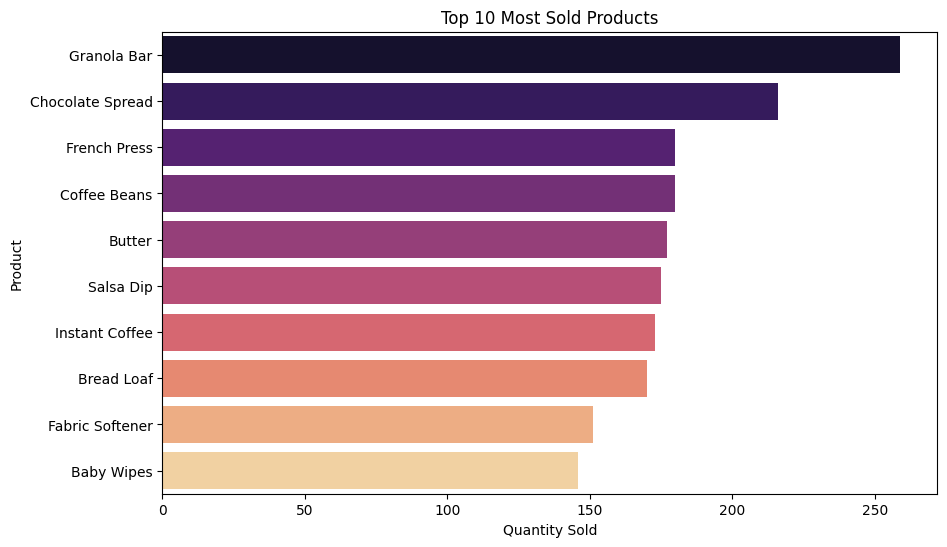

Interpretation: These products dominate sales volume, showing customer preferences.


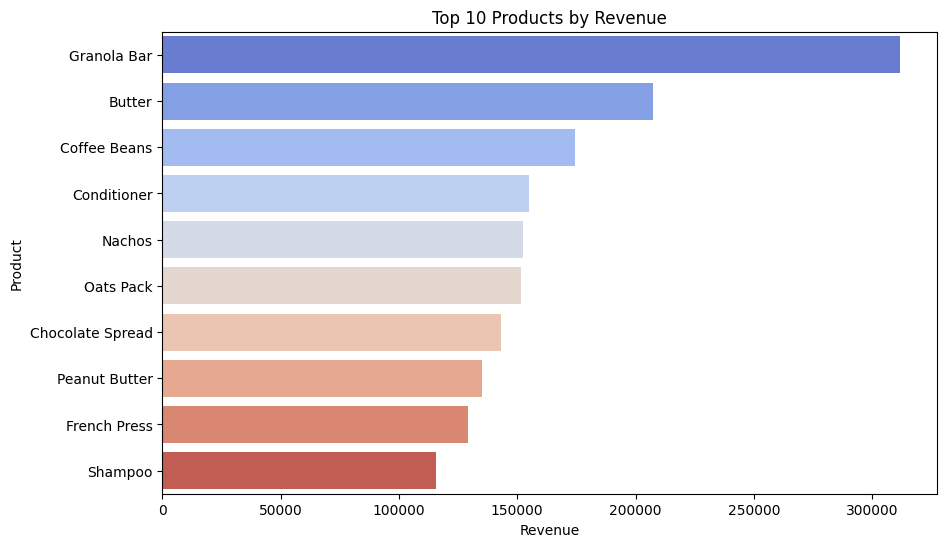

Interpretation: High-value items generate more revenue even if sold less frequently.


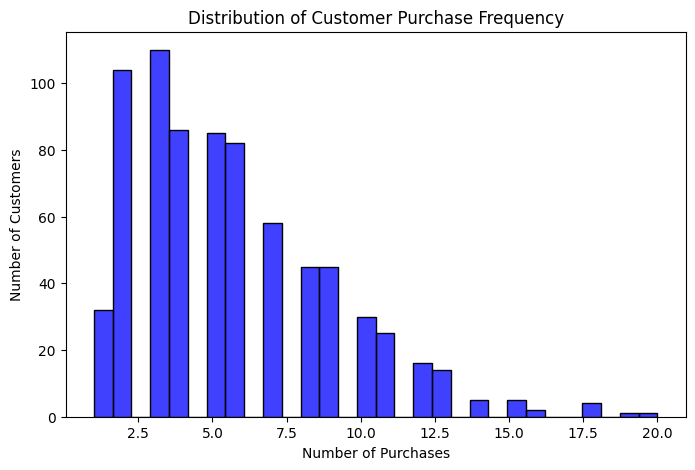

Interpretation: Most customers purchase only a few times, while a small group buys frequently.


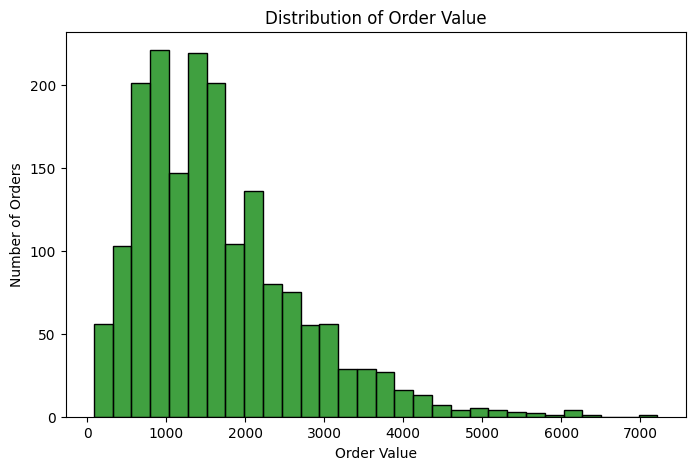

Interpretation: Majority of orders are low-value, but a few large orders contribute significantly.


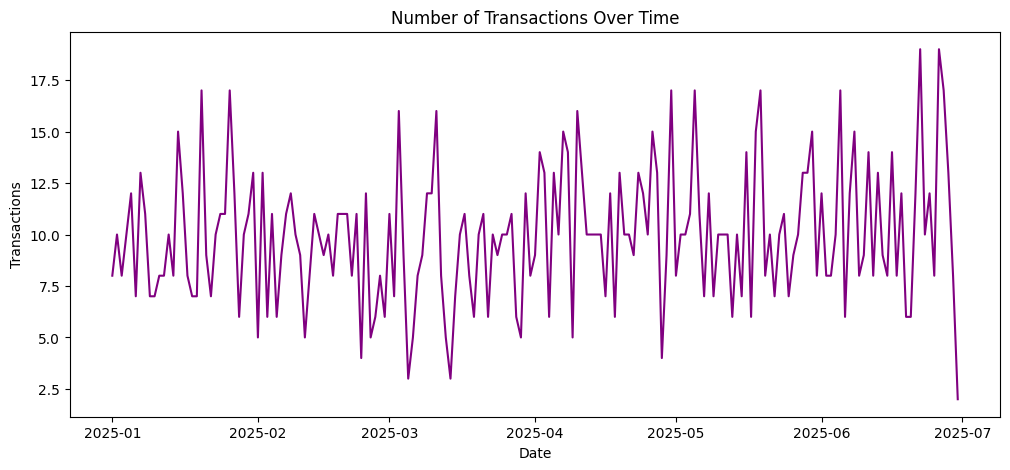

Interpretation: Peaks and troughs highlight busy and slow periods, guiding inventory and staffing decisions.


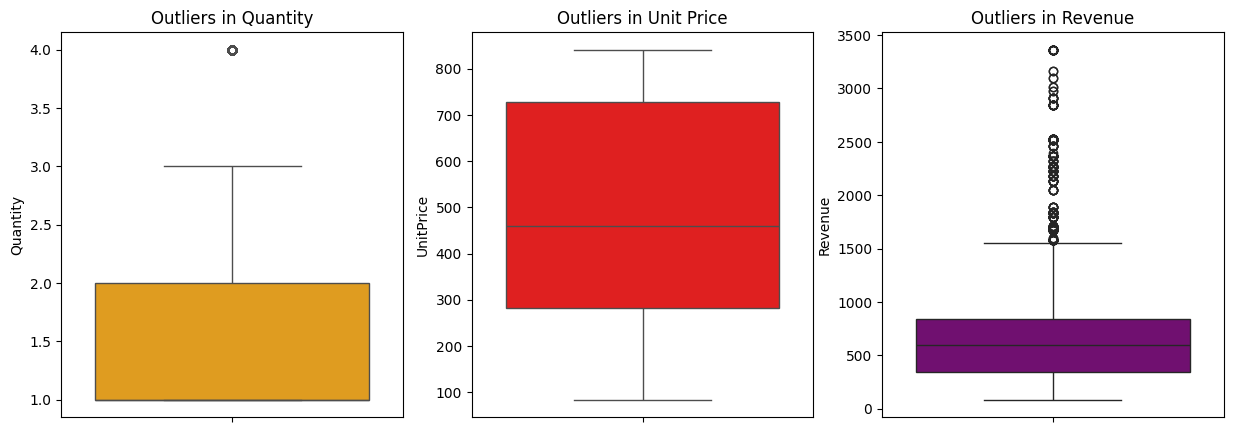

Interpretation: Extreme outliers exist in quantity and price, likely due to bulk orders or data entry errors.


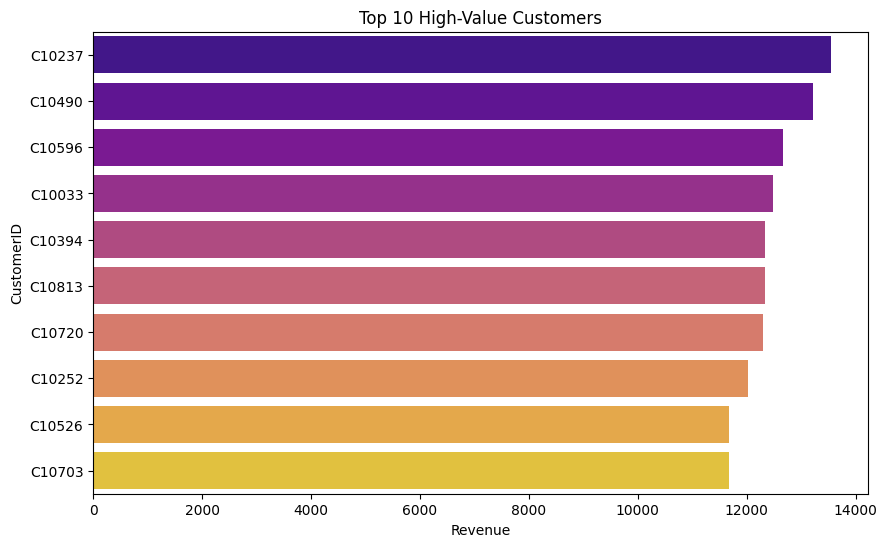

Interpretation: A small set of customers contribute disproportionately to total revenue.


In [25]:
# Step 9: Exploratory Data Analysis (EDA for your dataset)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings

# Suppress warnings (like datetime.utcnow deprecation)
warnings.filterwarnings("ignore")

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# 1. Top 10 Most Sold Products
top_products = df['ProductName'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, palette="magma")
plt.title("Top 10 Most Sold Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()
print("Interpretation: These products dominate sales volume, showing customer preferences.")

# 2. Top 10 Products by Revenue
product_revenue = df.groupby('ProductName')['Revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=product_revenue.values, y=product_revenue.index, palette="coolwarm")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()
print("Interpretation: High-value items generate more revenue even if sold less frequently.")

# 3. Distribution of Customer Purchase Frequency
plt.figure(figsize=(8,5))
sns.histplot(df.groupby('CustomerID')['TransactionID'].count(), bins=30, kde=False, color="blue")
plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()
print("Interpretation: Most customers purchase only a few times, while a small group buys frequently.")

# 4. Distribution of Order Value
order_value = df.groupby('TransactionID')['Revenue'].sum()
plt.figure(figsize=(8,5))
sns.histplot(order_value, bins=30, kde=False, color="green")
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")
plt.show()
print("Interpretation: Majority of orders are low-value, but a few large orders contribute significantly.")

# 5. Transactions Over Time
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')
daily_sales = df.groupby(df['TransactionDate'].dt.date)['TransactionID'].nunique()
plt.figure(figsize=(12,5))
daily_sales.plot(kind='line', color="purple")
plt.title("Number of Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Transactions")
plt.show()
print("Interpretation: Peaks and troughs highlight busy and slow periods, guiding inventory and staffing decisions.")

# 6. Outliers in Quantity, UnitPrice, Revenue
fig, axes = plt.subplots(1,3, figsize=(15,5))
sns.boxplot(y=df['Quantity'], ax=axes[0], color="orange")
axes[0].set_title("Outliers in Quantity")
sns.boxplot(y=df['UnitPrice'], ax=axes[1], color="red")
axes[1].set_title("Outliers in Unit Price")
sns.boxplot(y=df['Revenue'], ax=axes[2], color="purple")
axes[2].set_title("Outliers in Revenue")
plt.show()
print("Interpretation: Extreme outliers exist in quantity and price, likely due to bulk orders or data entry errors.")

# 7. Top 10 High-Value Customers
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_customers.values, y=top_customers.index, palette="plasma")
plt.title("Top 10 High-Value Customers")
plt.xlabel("Revenue")
plt.ylabel("CustomerID")
plt.show()
print("Interpretation: A small set of customers contribute disproportionately to total revenue.")


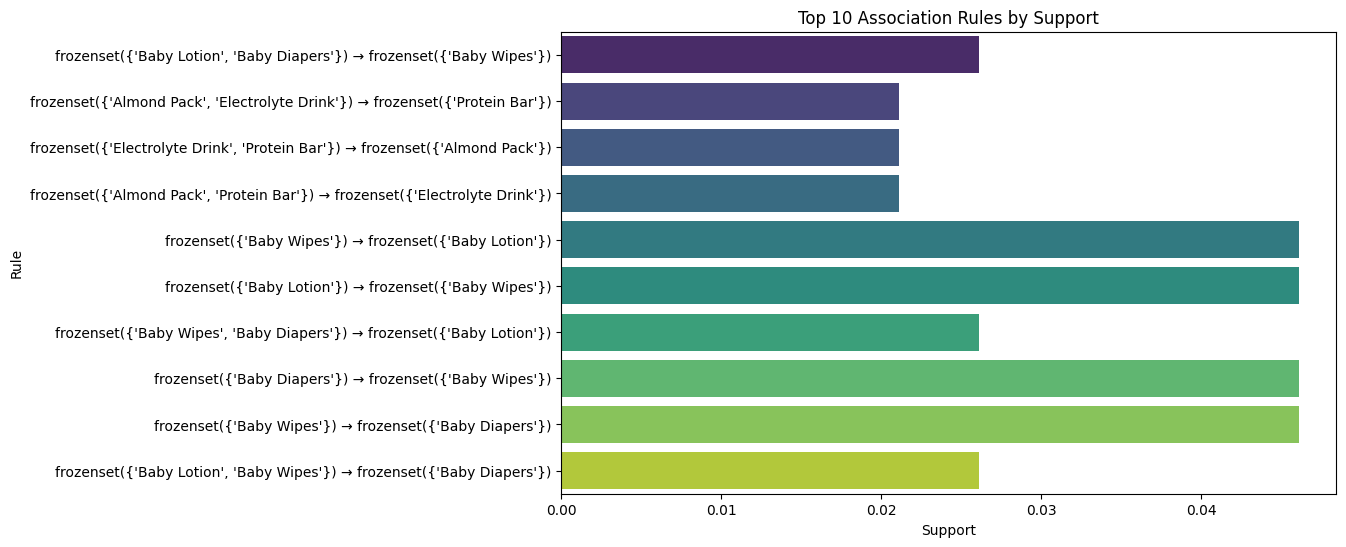

Interpretation: These rules occur most frequently in transactions, showing common product combinations.


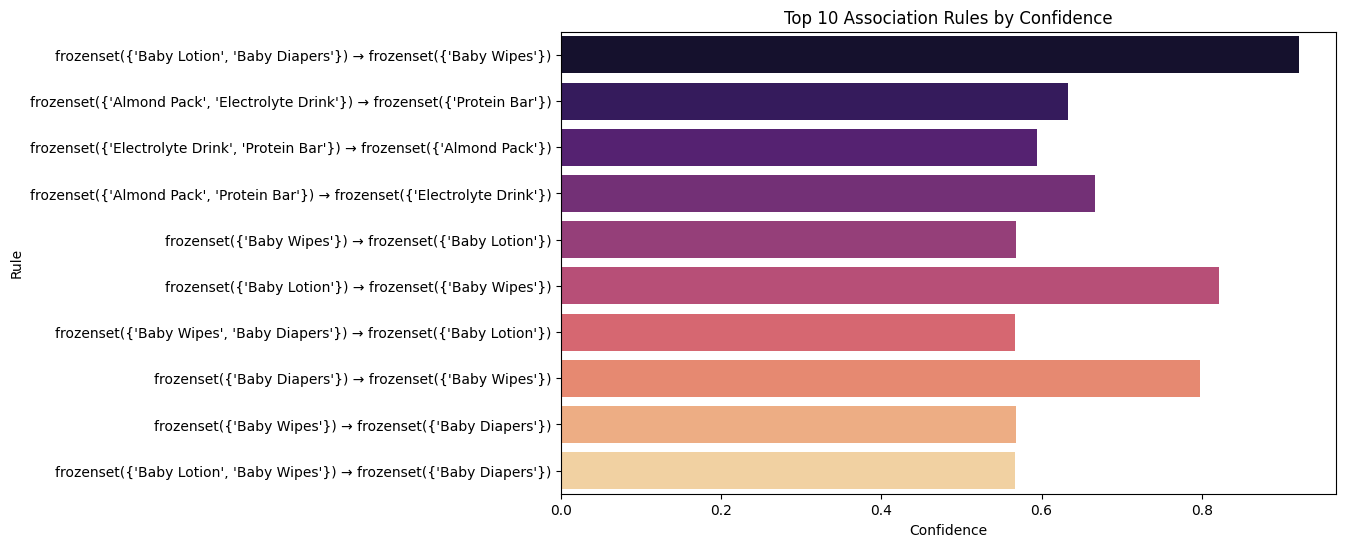

Interpretation: These rules have high reliability — when the antecedent is bought, the consequent is very likely to follow.


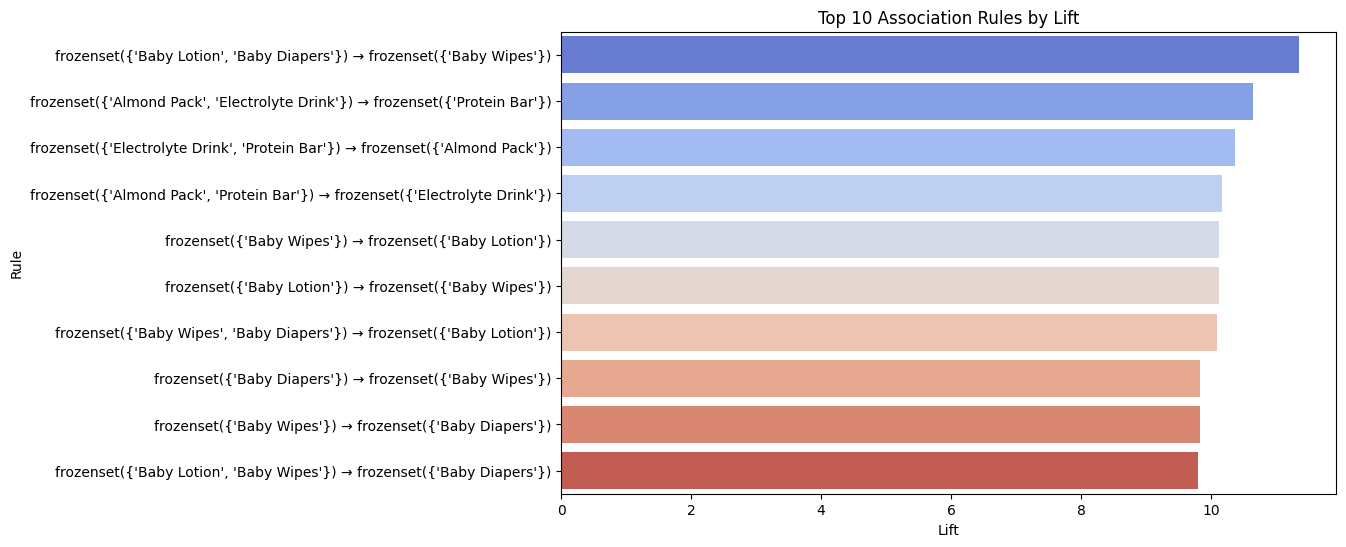

Interpretation: These rules show the strongest positive associations, meaning the items are bought together more often than random chance.


In [26]:
# Step 10: Visualization of Association Rules

import matplotlib.pyplot as plt
import seaborn as sns

# Select top 10 rules by lift for visualization
top_rules = filtered_rules.sort_values(by='lift', ascending=False).head(10)

# 1. Support values
plt.figure(figsize=(10,6))
sns.barplot(x=top_rules['support'], y=top_rules['antecedents'].astype(str) + " → " + top_rules['consequents'].astype(str), palette="viridis")
plt.title("Top 10 Association Rules by Support")
plt.xlabel("Support")
plt.ylabel("Rule")
plt.show()
print("Interpretation: These rules occur most frequently in transactions, showing common product combinations.")

# 2. Confidence values
plt.figure(figsize=(10,6))
sns.barplot(x=top_rules['confidence'], y=top_rules['antecedents'].astype(str) + " → " + top_rules['consequents'].astype(str), palette="magma")
plt.title("Top 10 Association Rules by Confidence")
plt.xlabel("Confidence")
plt.ylabel("Rule")
plt.show()
print("Interpretation: These rules have high reliability — when the antecedent is bought, the consequent is very likely to follow.")

# 3. Lift values
plt.figure(figsize=(10,6))
sns.barplot(x=top_rules['lift'], y=top_rules['antecedents'].astype(str) + " → " + top_rules['consequents'].astype(str), palette="coolwarm")
plt.title("Top 10 Association Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Rule")
plt.show()
print("Interpretation: These rules show the strongest positive associations, meaning the items are bought together more often than random chance.")
